In [ ]:
from google.colab import drive
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/TyreNet'
IMG_SIZE = 128


Mounted at /content/drive


tyre detection

In [ ]:
def letterbox_resize(img, size=(IMG_SIZE, IMG_SIZE)):
    """Resizes image to `size` preserving aspect ratio by adding black padding."""
    h, w = img.shape[:2]
    scale = min(size[0]/h, size[1]/w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (new_w, new_h))

    canvas = np.zeros((size[0], size[1], 3), dtype=np.uint8)
    y_off = (size[0] - new_h) // 2
    x_off = (size[1] - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas

def detect_and_crop_tire(img):
    """OpenCV heuristic to find and crop the largest dark circular object (the tire)."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return img
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    padding = 20
    x, y = max(0, x - padding), max(0, y - padding)
    w = min(img.shape[1] - x, w + 2 * padding)
    h = min(img.shape[0] - y, h + 2 * padding)
    return img[y:y+h, x:x+w]


data loading

STEP 2: Load Images and Labels

Loading Data...
Creating Solid Masks...


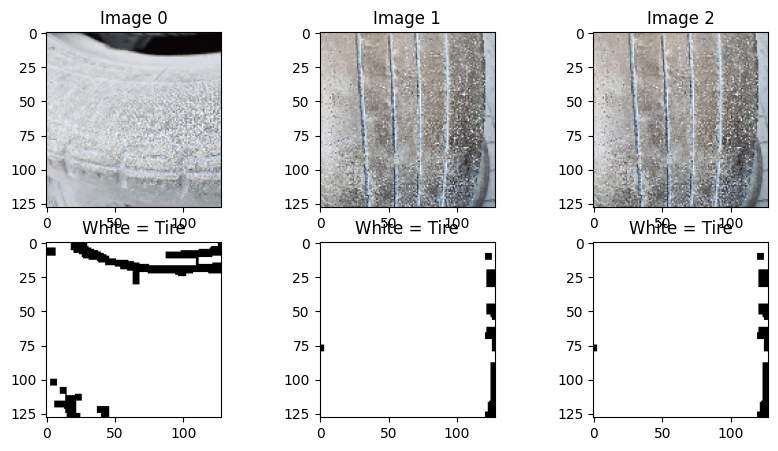

In [ ]:
def load_data(base_path):
    images, labels = [], []
    categories = ["Defective", "Good"]
    for category in categories:
        path = os.path.join(base_path, category)
        if not os.path.exists(path): continue
        for file in os.listdir(path):
            img = cv2.imread(os.path.join(path, file))
            if img is None: continue
            img = letterbox_resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(1.0 if category == "Good" else 0.0)
    return np.array(images) / 255.0, np.array(labels)

print("Loading Data...")
images, labels = load_data(data_path)

def create_mask(img):
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

    # ✨ ADAPTIVE THRESHOLD: Better for dusty tires and shadows
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    # Clean up small noise dots
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return np.expand_dims(mask / 255.0, axis=-1)

print("Creating Solid Masks...")
masks = np.array([create_mask(img) for img in images])
X_train, X_test, M_train, M_test, y_train, y_test = train_test_split(images, masks, labels, test_size=0.2, random_state=42)

# ✨ Verify results (Tires must be WHITE in the bottom row)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(2, 3, i+1); plt.imshow(images[i]); plt.title(f"Image {i}")
    plt.subplot(2, 3, i+4); plt.imshow(masks[i].squeeze(), cmap='gray'); plt.title("White = Tire")
plt.show()


Unet

In [ ]:
def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))

def build_improved_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    p1 = layers.MaxPooling2D()(c1)
    p1 = layers.Dropout(0.1)(p1)

    c2 = layers.Conv2D(64, 3, padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D()(c2)
    p2 = layers.Dropout(0.1)(p2)

    # Bottleneck
    b = layers.Conv2D(128, 3, padding='same')(p2)
    b = layers.BatchNormalization()(b)
    b = layers.Activation('relu')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(64, 3, padding='same')(u1)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('relu')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(32, 3, padding='same')(u2)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('relu')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=lambda y_true, y_pred: dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred),
        metrics=['accuracy']
    )
    return model

unet = build_improved_unet()
unet.fit(X_train, M_train, validation_data=(X_test, M_test), epochs=50, batch_size=8)


Epoch 1/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - accuracy: 0.8601 - loss: 0.6708 - val_accuracy: 0.9440 - val_loss: 0.6428
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9385 - loss: 0.4395 - val_accuracy: 0.9369 - val_loss: 0.5012
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9427 - loss: 0.3683 - val_accuracy: 0.9399 - val_loss: 0.3939
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9436 - loss: 0.3254 - val_accuracy: 0.9488 - val_loss: 0.3160
Epoch 5/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9457 - loss: 0.2922 - val_accuracy: 0.9462 - val_loss: 0.2917
Epoch 6/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9472 - loss: 0.2666 - val_accuracy: 0.9559 - val_loss: 0.2381
Epoch 7/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9474 - loss: 0.2484 - val_accuracy: 0.9559 - val_loss: 0.2253
Epoch 8/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9484 - loss: 0.2317 - val_acc

cnn classifier

In [ ]:
def build_rgb_mobilenet_classifier():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3)) # accept RGB images
    base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    x = layers.GlobalAveragePooling2D()(base_model(inputs))
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Step to crop images using the newly trained U-Net
def get_isolated_tires(unet_model, rgb_images):
    preds = unet_model.predict(rgb_images)
    clean_masks = (preds > 0.5).astype(np.float32)
    return np.array([rgb_images[i] * clean_masks[i] for i in range(len(rgb_images))])

print("Preparing RGB isolated tires for CNN training...")
train_cropped_rgb = get_isolated_tires(unet, X_train)
test_cropped_rgb = get_isolated_tires(unet, X_test)

cnn_improved = build_rgb_mobilenet_classifier()
cnn_improved.fit(train_cropped_rgb, y_train, validation_data=(test_cropped_rgb, y_test), epochs=30, batch_size=16)

# Fine-tuning
cnn_improved.layers[1].trainable = True
cnn_improved.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
cnn_improved.fit(train_cropped_rgb, y_train, validation_data=(test_cropped_rgb, y_test), epochs=10)
cnn_improved.save('/content/drive/MyDrive/cnn_classifier_rgb_v3.keras')


Preparing RGB isolated tires for CNN training...
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 48s 353ms/step - accuracy: 0.6922 - loss: 0.6175 - val_accuracy: 0.9000 - val_loss: 0.2876
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.8351 - loss: 0.3835 - val_accuracy: 0.9324 - val_loss: 0.2170
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8630 - loss: 0.3287 - val_accuracy: 0.9353 - val_loss: 0.1965
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8866 - loss: 0.2792 - val_accuracy: 0.9265 - val_loss: 0.1919
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8991 - loss: 0.2639 - val_accuracy: 0.9147 - val_loss: 0.1852
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9094 - loss: 0.2324 - val_accuracy: 0.9412 - val_loss: 0.1686
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


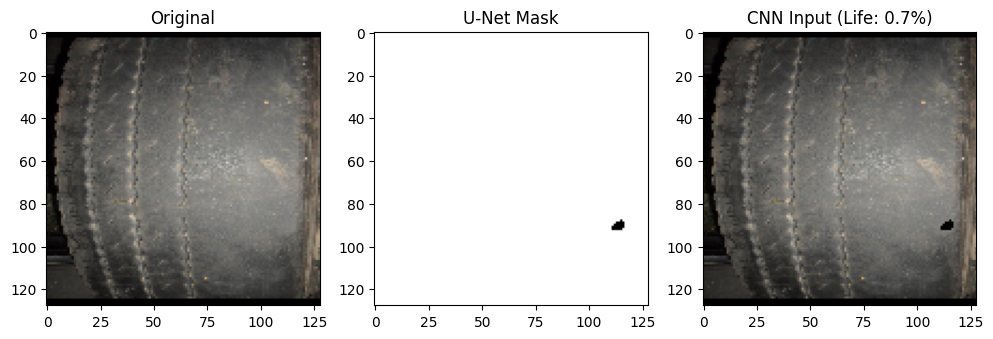

In [ ]:
def predict_tire_health_final(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    # Resize whole image
    crop = letterbox_resize(img, (IMG_SIZE, IMG_SIZE))
    input_img = np.expand_dims(crop / 255.0, axis=0)

    # 1. Get Mask
    mask = unet.predict(input_img)
    clean_mask = (mask > 0.5).astype(np.float32)

    # 2. Extract texture (Image * Mask)
    # This sends the actual rubber texture to the CNN
    rgb_input = input_img * clean_mask

    # 3. Classify
    pred_prob = cnn_improved.predict(rgb_input)[0][0]
    life = pred_prob * 100

    # Show visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); plt.title("Original")
    plt.subplot(1, 3, 2); plt.imshow(clean_mask[0].squeeze(), cmap='gray'); plt.title("U-Net Mask")
    plt.subplot(1, 3, 3); plt.imshow(rgb_input[0][..., ::-1]); plt.title(f"CNN Input (Life: {life:.1f}%)")
    plt.show()

predict_tire_health_final('/content/drive/MyDrive/dummytest/t3.jpg')


In [ ]:
unet.save('/content/drive/MyDrive/unet_tire_wear_v3.h5')
print("U-Net saved to Drive as 'unet_tire_wear_v2.h5'")

U-Net saved to Drive as 'unet_tire_wear_v2.h5'
